## Import Libraries

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px
import random

## Load Dataset

In [22]:
data = pd.read_csv('Pokemon.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [23]:
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


## Create Power Column

In [24]:
def determine_power(row):
    t1 = str(row['Type 1']).upper()
    t2 = row['Type 2']
    
    # If Type 2 is empty or NaN, Power is just Type 1
    if pd.isna(t2) or str(t2).strip() == "":
        return t1
    else:
        # Otherwise, combine them into a Hybrid Power
        return f"{t1}-{str(t2).upper()}"

# 3. Apply the function to create the new column
data['Power'] = data.apply(determine_power, axis=1)

## Data Augmentation

In [25]:

stat_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
num_samples_per_pokemon = 100 

augmented_data = []

for index, row in data.iterrows():

    original_row = row.to_dict()
    original_row['Is_Augmented'] = 0 
    augmented_data.append(original_row)
    
    for _ in range(num_samples_per_pokemon - 1): 
        
        new_row = row.to_dict()
        
        for stat in stat_columns:

            base_val = new_row[stat]
            noise_val = np.random.normal(loc=base_val, scale=base_val * 0.05)
            new_row[stat] = max(1, int(round(noise_val)))

            
            
        new_row['Total'] = sum(new_row[stat] for stat in stat_columns)
        new_row['Is_Augmented'] = 1
        augmented_data.append(new_row)


augmented_df = pd.DataFrame(augmented_data)

augmented_df['Legendary'] = augmented_df['Legendary'].astype(int)

# augmented_df.to_csv('augmented_pokemon.csv', index=False)

print(f"Original shape: {data.shape}")
print(f"Augmented shape: {augmented_df.shape}")

Original shape: (800, 14)
Augmented shape: (80000, 15)


## View Augmented Data

In [26]:
name = random.choice(data["Name"].unique())
print(f"Randomly selected Pokémon: {name}")

print(data[data["Name"]==name])

augmented_df[augmented_df["Name"]==name].sample(20)

Randomly selected Pokémon: Articuno
       #      Name Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  \
156  144  Articuno    Ice  Flying    580  90      85      100       95   

     Sp. Def  Speed  Generation  Legendary       Power  
156      125     85           1       True  ICE-FLYING  


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Power,Is_Augmented
15687,144,Articuno,Ice,Flying,582,93,87,94,100,125,83,1,1,ICE-FLYING,1
15640,144,Articuno,Ice,Flying,559,87,81,102,85,120,84,1,1,ICE-FLYING,1
15607,144,Articuno,Ice,Flying,583,88,88,110,96,118,83,1,1,ICE-FLYING,1
15681,144,Articuno,Ice,Flying,575,91,87,101,92,122,82,1,1,ICE-FLYING,1
15685,144,Articuno,Ice,Flying,578,95,79,102,88,127,87,1,1,ICE-FLYING,1
15665,144,Articuno,Ice,Flying,574,94,91,102,92,115,80,1,1,ICE-FLYING,1
15643,144,Articuno,Ice,Flying,596,87,90,111,98,125,85,1,1,ICE-FLYING,1
15691,144,Articuno,Ice,Flying,586,95,90,104,95,114,88,1,1,ICE-FLYING,1
15616,144,Articuno,Ice,Flying,561,91,84,93,94,120,79,1,1,ICE-FLYING,1
15647,144,Articuno,Ice,Flying,573,88,84,94,97,133,77,1,1,ICE-FLYING,1


## Augmented Data Range

HP range: 1 - 281
Attack range: 4 - 210
Defense range: 4 - 260
Sp. Atk range: 8 - 223
Sp. Def range: 17 - 260
Speed range: 4 - 204


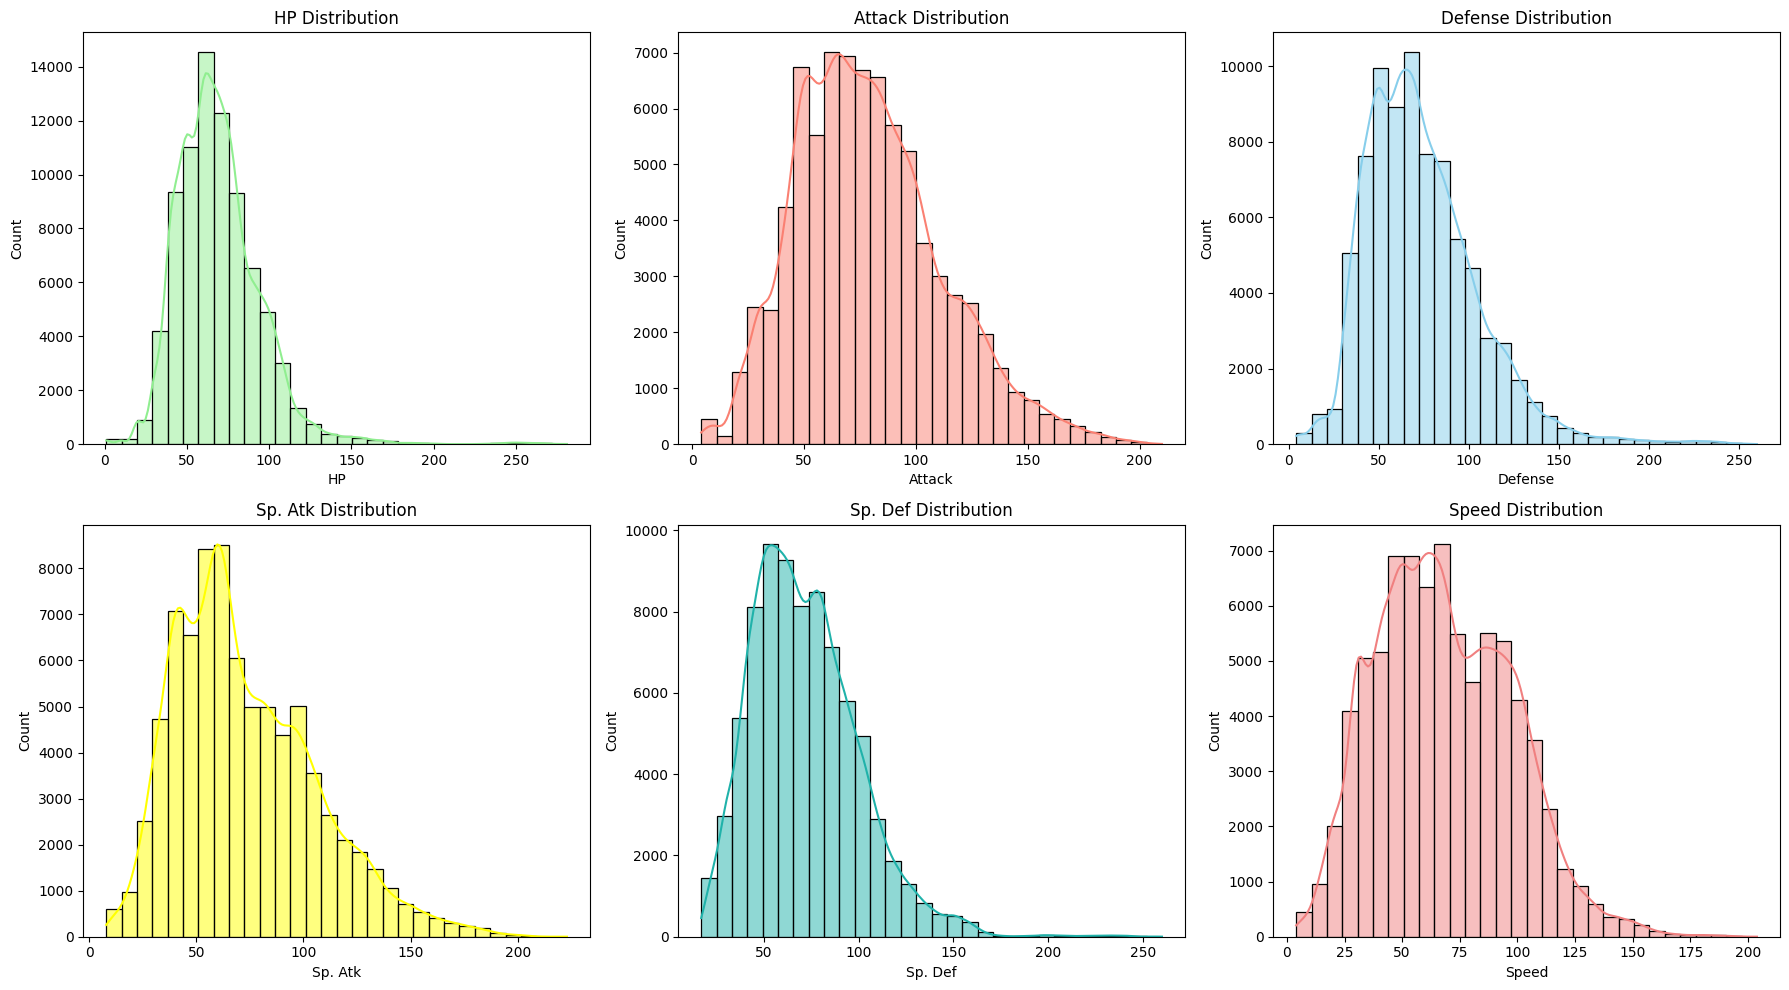

In [27]:

print(f"HP range: {augmented_df['HP'].min()} - {augmented_df['HP'].max()}")
print(f"Attack range: {augmented_df['Attack'].min()} - {augmented_df['Attack'].max()}")
print(f"Defense range: {augmented_df['Defense'].min()} - {augmented_df['Defense'].max()}")
print(f"Sp. Atk range: {augmented_df['Sp. Atk'].min()} - {augmented_df['Sp. Atk'].max()}")
print(f"Sp. Def range: {augmented_df['Sp. Def'].min()} - {augmented_df['Sp. Def'].max()}")
print(f"Speed range: {augmented_df['Speed'].min()} - {augmented_df['Speed'].max()}")



fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(augmented_df['HP'], bins=30, kde=True, ax=axes[0, 0], color='lightgreen')
axes[0, 0].set_title('HP Distribution')
sns.histplot(augmented_df['Attack'], bins=30, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Attack Distribution')
sns.histplot(augmented_df['Defense'], bins=30, kde=True, ax=axes[0, 2], color='skyblue')
axes[0, 2].set_title('Defense Distribution')
sns.histplot(augmented_df['Sp. Atk'], bins=30, kde=True, ax=axes[1, 0], color='yellow')   
axes[1, 0].set_title('Sp. Atk Distribution')
sns.histplot(augmented_df['Sp. Def'], bins=30, kde=True, ax=axes[1, 1], color='lightseagreen')
axes[1, 1].set_title('Sp. Def Distribution')
sns.histplot(augmented_df['Speed'], bins=30, kde=True, ax=axes[1, 2], color='lightcoral')
axes[1, 2].set_title('Speed Distribution')
plt.tight_layout()
plt.show()



## Prepare ML Features and Labels

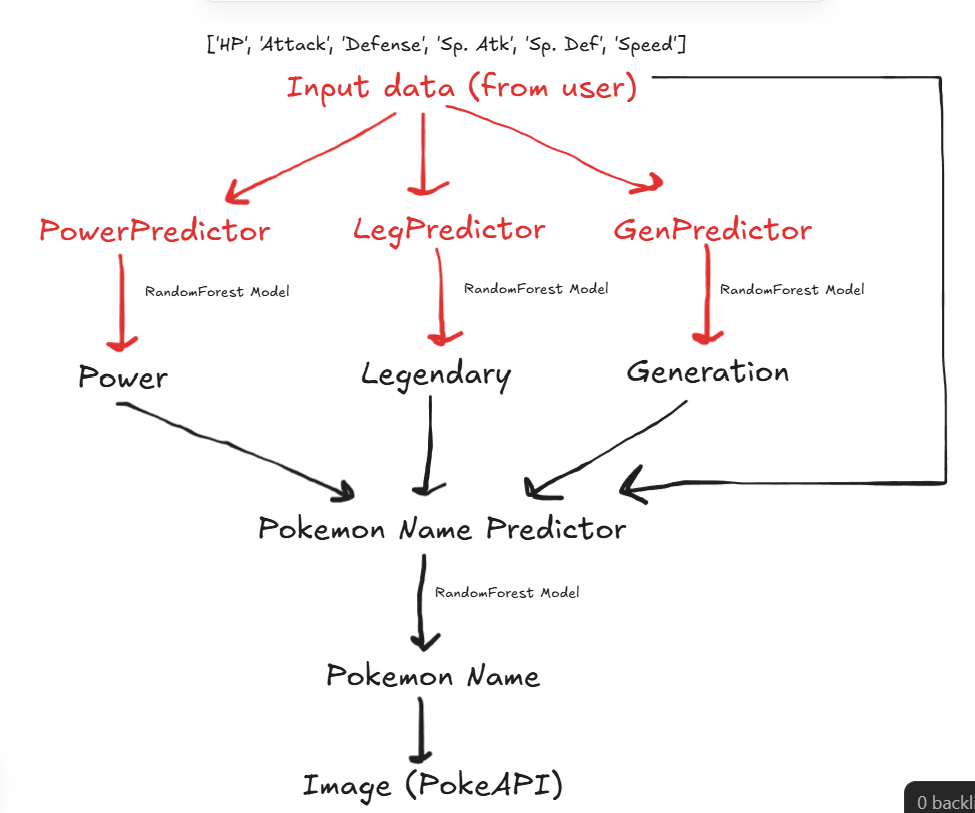

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X1_without_power = augmented_df[['HP' , 'Attack' , 'Defense' , 'Sp. Atk' , 'Sp. Def' , 'Speed']]
X2_with_power = augmented_df[['HP' , 'Attack' , 'Defense' , 'Sp. Atk' , 'Sp. Def' , 'Speed' ,'Legendary','Generation', 'Power']]

X2_with_power = pd.get_dummies(X2_with_power, columns=['Power'] , drop_first=True)

y_power_label = augmented_df['Power']
y_name_label = augmented_df['Name']
y_legendary_label = augmented_df['Legendary']
y_generation_label = augmented_df['Generation']


power_encoder = LabelEncoder()
name_encoder = LabelEncoder()
legendary_encoder = LabelEncoder()
generation_encoder = LabelEncoder()


y_power_encoded = power_encoder.fit_transform(y_power_label)
y_name_encoded = name_encoder.fit_transform(y_name_label)
y_legendary_encoded = legendary_encoder.fit_transform(y_legendary_label)
y_generation_encoded = generation_encoder.fit_transform(y_generation_label)



X_train_topower  , X_test_topower, y_train_power, y_test_power = train_test_split(X1_without_power, y_power_encoded, test_size=0.1, random_state=42 , stratify=y_power_encoded , shuffle=True)

X_train_toname, X_test_toname, y_train_name, y_test_name = train_test_split(X2_with_power, y_name_encoded, test_size=0.1, random_state=42 , stratify=y_name_encoded , shuffle=True)

X_train_tolegendary, X_test_tolegendary, y_train_legendary, y_test_legendary = train_test_split(X1_without_power, y_legendary_encoded, test_size=0.1, random_state=42 , stratify=y_legendary_encoded , shuffle=True)

X_train_togeneration, X_test_togeneration, y_train_generation, y_test_generation = train_test_split(X1_without_power, y_generation_encoded, test_size=0.1, random_state=42 , stratify=y_generation_encoded , shuffle=True)



## Display Training Columns

In [29]:
training_columns = X2_with_power.columns.tolist()
print(f"Model 2 expects {len(training_columns)} columns:")
training_columns

Model 2 expects 161 columns:


['HP',
 'Attack',
 'Defense',
 'Sp. Atk',
 'Sp. Def',
 'Speed',
 'Legendary',
 'Generation',
 'Power_BUG-ELECTRIC',
 'Power_BUG-FIGHTING',
 'Power_BUG-FIRE',
 'Power_BUG-FLYING',
 'Power_BUG-GHOST',
 'Power_BUG-GRASS',
 'Power_BUG-GROUND',
 'Power_BUG-POISON',
 'Power_BUG-ROCK',
 'Power_BUG-STEEL',
 'Power_BUG-WATER',
 'Power_DARK',
 'Power_DARK-DRAGON',
 'Power_DARK-FIGHTING',
 'Power_DARK-FIRE',
 'Power_DARK-FLYING',
 'Power_DARK-GHOST',
 'Power_DARK-ICE',
 'Power_DARK-PSYCHIC',
 'Power_DARK-STEEL',
 'Power_DRAGON',
 'Power_DRAGON-ELECTRIC',
 'Power_DRAGON-FAIRY',
 'Power_DRAGON-FIRE',
 'Power_DRAGON-FLYING',
 'Power_DRAGON-GROUND',
 'Power_DRAGON-ICE',
 'Power_DRAGON-PSYCHIC',
 'Power_ELECTRIC',
 'Power_ELECTRIC-DRAGON',
 'Power_ELECTRIC-FAIRY',
 'Power_ELECTRIC-FIRE',
 'Power_ELECTRIC-FLYING',
 'Power_ELECTRIC-GHOST',
 'Power_ELECTRIC-GRASS',
 'Power_ELECTRIC-ICE',
 'Power_ELECTRIC-NORMAL',
 'Power_ELECTRIC-STEEL',
 'Power_ELECTRIC-WATER',
 'Power_FAIRY',
 'Power_FAIRY-FLYING',
 'P

## Model Training Code

In [30]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score



# model_power_predictor = RandomForestClassifier()

# model_power_predictor.fit(X_train_topower, y_train_power)
# y_pred_power = model_power_predictor.predict(X_test_topower)


# accuracy = accuracy_score(y_test_power, y_pred_power)
# precision = precision_score(y_test_power, y_pred_power, average='weighted')
# recall = recall_score(y_test_power, y_pred_power, average='weighted')
# f1 = f1_score(y_test_power, y_pred_power, average='weighted')


# print("Model 1 (Predicting Power):")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")

# print("=" * 30)


# model_legendary_predictor = RandomForestClassifier()

# model_legendary_predictor.fit(X_train_tolegendary, y_train_legendary)
# y_pred_legendary = model_legendary_predictor.predict(X_test_tolegendary)


# accuracy = accuracy_score(y_test_legendary, y_pred_legendary)
# precision = precision_score(y_test_legendary, y_pred_legendary, average='weighted')
# recall = recall_score(y_test_legendary, y_pred_legendary, average='weighted')
# f1 = f1_score(y_test_legendary, y_pred_legendary, average='weighted')


# print("Model 2 (Predicting Legendary):")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# # print(f"F1 Score: {f1:.4f}")

# print("=" * 30)

# model_generation_predictor = RandomForestClassifier()

# model_generation_predictor.fit(X_train_togeneration, y_train_generation)
# y_pred_generation = model_generation_predictor.predict(X_test_togeneration)


# accuracy = accuracy_score(y_test_generation, y_pred_generation)
# precision = precision_score(y_test_generation, y_pred_generation, average='weighted')
# recall = recall_score(y_test_generation, y_pred_generation, average='weighted')
# f1 = f1_score(y_test_generation, y_pred_generation, average='weighted')


# print("Model 3 (Predicting Generation):")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")

# print("=" * 30)

# model_name_predictor = RandomForestClassifier()

# model_name_predictor.fit(X_train_toname, y_train_name)
# y_pred_name = model_name_predictor.predict(X_test_toname)


# accuracy2 = accuracy_score(y_test_name, y_pred_name)
# precision2 = precision_score(y_test_name, y_pred_name, average='weighted')
# recall2 = recall_score(y_test_name, y_pred_name, average='weighted')
# f1_2 = f1_score(y_test_name, y_pred_name, average='weighted')

# print("Model 4 (Predicting Name):")
# print(f"Accuracy: {accuracy2:.4f}")
# print(f"Precision: {precision2:.4f}")
# print(f"Recall: {recall2:.4f}")
# print(f"F1 Score: {f1_2:.4f}")



## Model Accuracy Results

Model 1 (Predicting Power):
- Accuracy: 0.9539
- Precision: 0.9539
- Recall: 0.9539
- F1 Score: 0.9538

==============================

Model 2 (Predicting Legendary):
- Accuracy: 0.9915
- Precision: 0.9914
- Recall: 0.9915
- F1 Score: 0.9915

==============================

Model 3 (Predicting Generation):
- Accuracy: 0.9599
- Precision: 0.9599
- Recall: 0.9599
- F1 Score: 0.9599

==============================

Model 4 (Predicting Name):
- Accuracy: 0.9935
- Precision: 0.9935
- Recall: 0.9935
- F1 Score: 0.9934

## Train Models

In [31]:
from sklearn.ensemble import RandomForestClassifier


PowerPredictor = RandomForestClassifier()
PowerPredictor.fit(X1_without_power, y_power_encoded)


LegendaryPredictor = RandomForestClassifier()
LegendaryPredictor.fit(X1_without_power, y_legendary_encoded)


GenerationPredictor = RandomForestClassifier()
GenerationPredictor.fit(X1_without_power, y_generation_encoded)


NamePredictor = RandomForestClassifier()
NamePredictor.fit(X2_with_power, y_name_encoded)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Save Models PKL

In [32]:
# import os
# import joblib

# predict_folder = 'models\predictors'
# encoder_folder = 'models\encoders'

# if not os.path.exists(predict_folder):
#     os.makedirs(predict_folder)

# if not os.path.exists(encoder_folder):
#     os.makedirs(encoder_folder)

# joblib.dump(PowerPredictor, os.path.join(predict_folder, 'PowerPredictor.pkl') , compress=3)
# print(f"Model saved as {'PowerPredictor.pkl'}")
# joblib.dump(NamePredictor, os.path.join(predict_folder, 'NamePredictor.pkl') ,  compress=3)
# print(f"Model saved as {'NamePredictor.pkl'}")
# joblib.dump(LegendaryPredictor, os.path.join(predict_folder, 'LegendaryPredictor.pkl') ,  compress=3)
# print(f"Model saved as {'LegendaryPredictor.pkl'}")
# joblib.dump(GenerationPredictor, os.path.join(predict_folder, 'GenerationPredictor.pkl') ,  compress=3)
# print(f"Model saved as {'GenerationPredictor.pkl'}")


# joblib.dump(power_encoder, os.path.join(encoder_folder, 'power_encoder.pkl') , compress=3)
# print(f"Model saved as {'power_encoder.pkl'}")
# joblib.dump(name_encoder, os.path.join(encoder_folder, 'name_encoder.pkl') ,  compress=3)
# print(f"Model saved as {'name_encoder.pkl'}")
# joblib.dump(legendary_encoder, os.path.join(encoder_folder, 'legendary_encoder.pkl') ,  compress=3)
# print(f"Model saved as {'legendary_encoder.pkl'}")
# joblib.dump(generation_encoder, os.path.join(encoder_folder, 'generation_encoder.pkl') ,  compress=3)
# print(f"Model saved as {'generation_encoder.pkl'}")


## Create Pokemon Display Function

In [33]:
import requests
from IPython.display import Image, display, HTML

# Build name -> Pokédex ID map directly from your CSV
name_to_id = dict(zip(data['Name'], data['#']))

print(f"Lookup table ready: {len(name_to_id)} Pokémon")

def show_pokemon(predicted_name):
    pokedex_id = name_to_id.get(predicted_name)
    if pokedex_id is None:
        print(f"Not found: {predicted_name}")
        return
    
    url = f"https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/official-artwork/{pokedex_id}.png"
    display(HTML(f'<img src="{url}" width="200px"/>'))

Lookup table ready: 800 Pokémon


## Load Models Code

In [34]:
# import joblib

# PowerPredictor = joblib.load('models/predictors/PowerPredictor.pkl')
# LegendaryPredictor = joblib.load('models/predictors/LegendaryPredictor.pkl')
# GenerationPredictor = joblib.load('models/predictors/GenerationPredictor.pkl')
# NamePredictor = joblib.load('models/predictors/NamePredictor.pkl')

# power_encoder = joblib.load('models/encoders/power_encoder.pkl')
# name_encoder = joblib.load('models/encoders/name_encoder.pkl')
# legendary_encoder = joblib.load('models/encoders/legendary_encoder.pkl')
# generation_encoder = joblib.load('models/encoders/generation_encoder.pkl')

## Predict Pokemon from Stats

In [46]:
health_point = random.randint(augmented_df['HP'].min(), augmented_df['HP'].max())
print(f"Randomly selected HP value: {health_point}")

attack = random.randint(augmented_df['Attack'].min(), augmented_df['Attack'].max())
print(f"Randomly selected Attack value: {attack}")

defense = random.randint(augmented_df['Defense'].min(), augmented_df['Defense'].max())
print(f"Randomly selected Defense value: {defense}")

sp_atk = random.randint(augmented_df['Sp. Atk'].min(), augmented_df['Sp. Atk'].max())
print(f"Randomly selected Sp. Atk value: {sp_atk}")

sp_def = random.randint(augmented_df['Sp. Def'].min(), augmented_df['Sp. Def'].max())
print(f"Randomly selected Sp. Def value: {sp_def}")

speed = random.randint(augmented_df['Speed'].min(), augmented_df['Speed'].max())
print(f"Randomly selected Speed value: {speed}")



new_pokemon = pd.DataFrame({
    'HP': [health_point],
    'Attack': [attack],
    'Defense': [defense],
    'Sp. Atk': [sp_atk],
    'Sp. Def': [sp_def],
    'Speed': [speed]
    })



# new_pokemon = pd.DataFrame({
#     'HP': [78],
#     'Attack': [84],
#     'Defense': [78],
#     'Sp. Atk': [109],
#     'Sp. Def': [85],
#     'Speed': [100],
#     })


predicted_power_encoded = PowerPredictor.predict(new_pokemon)[0]
predicted_power = power_encoder.inverse_transform([predicted_power_encoded])[0]

print(f"Predicted Power: {predicted_power}")

predicted_legendary_encoded = LegendaryPredictor.predict(new_pokemon)[0]
predicted_legendary = legendary_encoder.inverse_transform([predicted_legendary_encoded])[0]

print(f"Predicted Legendary: {predicted_legendary}")

predicted_generation_encoded = GenerationPredictor.predict(new_pokemon)[0]
predicted_generation = generation_encoder.inverse_transform([predicted_generation_encoded])[0]

print(f"Predicted Generation: {predicted_generation}")

new_pokemon['Legendary'] = predicted_legendary
new_pokemon['Generation'] = predicted_generation
new_pokemon[[f'Power_{predicted_power}']] = 1


new_pokemon = new_pokemon.reindex(columns=training_columns, fill_value=0)


predicted_name_encoded = NamePredictor.predict(new_pokemon)[0]
predicted_name = name_encoder.inverse_transform([predicted_name_encoded])[0]

print(50 * "=")
print(f"Predicted Pokémon: {predicted_name}")
print(f"Pokemon Power is: {data[data['Name'] == predicted_name]['Power'].iloc[0]}")
print(f"Pokemon Legendary is: {data[data['Name'] == predicted_name]['Legendary'].iloc[0]}")
print(f"Pokemon Generation is: {data[data['Name'] == predicted_name]['Generation'].iloc[0]}")

show_pokemon(predicted_name)

new_pokemon[[f'Power_{predicted_power}']]

Randomly selected HP value: 26
Randomly selected Attack value: 155
Randomly selected Defense value: 214
Randomly selected Sp. Atk value: 211
Randomly selected Sp. Def value: 167
Randomly selected Speed value: 50
Predicted Power: ROCK-FAIRY
Predicted Legendary: 1
Predicted Generation: 6
Predicted Pokémon: Diancie
Pokemon Power is: ROCK-FAIRY
Pokemon Legendary is: True
Pokemon Generation is: 6


,Power_ROCK-FAIRY
0,1


## Define Predictor Function and Generate Team

In [14]:
from tqdm import tqdm

def PokemonPredictor(health_point = None , attack = None , defense = None , sp_atk = None , sp_def = None , speed = None) : 

    if health_point is None:
        health_point = random.randint(augmented_df['HP'].min(), augmented_df['HP'].max())

    if attack is None:
        attack = random.randint(augmented_df['Attack'].min(), augmented_df['Attack'].max())

    if defense is None:
        defense = random.randint(augmented_df['Defense'].min(), augmented_df['Defense'].max())

    if sp_atk is None:
        sp_atk = random.randint(augmented_df['Sp. Atk'].min(), augmented_df['Sp. Atk'].max())

    if sp_def is None:
        sp_def = random.randint(augmented_df['Sp. Def'].min(), augmented_df['Sp. Def'].max())

    if speed is None:
        speed = random.randint(augmented_df['Speed'].min(), augmented_df['Speed'].max())



    new_pokemon = pd.DataFrame({
        'HP': [health_point],
        'Attack': [attack],
        'Defense': [defense],
        'Sp. Atk': [sp_atk],
        'Sp. Def': [sp_def],
        'Speed': [speed]
        })
    

    predicted_power_encoded = PowerPredictor.predict(new_pokemon)[0]
    predicted_power = power_encoder.inverse_transform([predicted_power_encoded])[0]

    predicted_legendary_encoded = LegendaryPredictor.predict(new_pokemon)[0]
    predicted_legendary = legendary_encoder.inverse_transform([predicted_legendary_encoded])[0]

    predicted_generation_encoded = GenerationPredictor.predict(new_pokemon)[0]
    predicted_generation = generation_encoder.inverse_transform([predicted_generation_encoded])[0]

    new_pokemon['Legendary'] = predicted_legendary
    new_pokemon['Generation'] = predicted_generation
    new_pokemon[[f'Power_{predicted_power}']] = 1


    new_pokemon = new_pokemon.reindex(columns=training_columns, fill_value=0)


    predicted_name_encoded = NamePredictor.predict(new_pokemon)[0]
    predicted_name = name_encoder.inverse_transform([predicted_name_encoded])[0]

    
    return predicted_name 


team = []

for _ in tqdm(range(10000), desc="Generating team"):

    pokemon = PokemonPredictor()
    team.append(pokemon)


team = set(team)

print(f"after 10000 iterations, we got {len(team)} unique pokemons in the team")








    

Generating team: 100%|██████████| 10000/10000 [05:27<00:00, 30.58it/s]

after 10000 iterations, we got 429 unique pokemons in the team
